# Toxic maker-flow filtering: walk-forward backtest

End-to-end backtest of the PnL-based toxic-flow filter on BTC perps.

**Pipeline.** A regression model predicts the per-trade markout PnL (`pnl_{tau}s`, rebate included); toxicity is the negated prediction. On each walk-forward window the model is trained on `train_model`, the filter threshold is tuned on `calib` (exact vectorized sweep, subject to the filter-rate budget and the turnover floor), and the filter is evaluated on the out-of-sample `test` month.

**Score.** `score = pnl_kept - pnl_all` (bps, notional-weighted), i.e. the improvement in average markout per dollar of kept turnover versus trading everything.

**Configurations compared.**
1. `base` - 16 base features, single LightGBM-Huber regressor.
2. `ensemble_rank` (production) - 40 advanced features (base + signed / relative / liquidation-battery), ensemble of 4 LightGBM-Huber regressors with different `huber_alpha` and tree shapes, aggregated by prediction ranks (scale-free, matches the rank-based thresholding downstream).

**Data.** Expects the enriched dataset at `data/enriched/btc_sub40.parquet` (every 40th trade of Binance BTCUSDT perp, Nov 2025 - Apr 2026, built from raw trades / BBO / liquidations). Set `BUILD_DATASET = True` below to build it from raw files first (compute-heavy, ~35 min).

In [1]:
import sys
from pathlib import Path

import numpy as np
import polars as pl

sys.path.insert(0, "src")

from data import DataConfig, build_dataset
from experiment import WalkForwardConfig, run_experiment_from_df, results_to_frame
from features import add_derived_features, get_feature_set
import utilities as util

INSTRUMENT = "btc"
TAU = 120                                  # markout horizon for the target, s
MAX_FILTER_RATES = [0.05, 0.10, 0.20, 0.30]
DATA_PATH = Path("data/enriched/btc_sub40.parquet")

BUILD_DATASET = False                      # True -> build DATA_PATH from raw files
RAW_DIR = Path("data/raw")                 # binance_trades/, binance_booktickers/,
                                           # binance_liquidations/, bybit_liquidations/
SUBSAMPLE_RATE = 40

In [2]:
if BUILD_DATASET:
    build_dataset(
        trades_path      = RAW_DIR / "binance_trades/perp_btcusdt.parquet",
        bbo_path         = RAW_DIR / "binance_booktickers/perp_btcusdt.parquet",
        liq_binance_path = RAW_DIR / "binance_liquidations/perp_btcusdt.parquet",
        liq_bybit_path   = RAW_DIR / "bybit_liquidations/btcusdt.parquet",
        output_path      = DATA_PATH,
        config           = DataConfig(),
        subsample_rate   = SUBSAMPLE_RATE,
        overwrite        = True,
    )

## 1. Load data

In [3]:
df = pl.read_parquet(DATA_PATH)
df = add_derived_features(df)

print(f"rows: {df.height:,}")
df.select(
    pl.from_epoch("timestamp", time_unit="us").min().alias("start"),
    pl.from_epoch("timestamp", time_unit="us").max().alias("end"),
)

rows: 20,100,882


start,end
datetime[μs],datetime[μs]
2025-11-01 00:00:00.015,2026-04-28 23:59:56.220


## 2. Walk-forward runs

Five expanding windows W1-W5 (train from 2025-11-01, one OOS test month each, 7-day embargo). The calibration slice is the last 20% of the train period by time.

In [4]:
config_base = WalkForwardConfig(
    instrument       = INSTRUMENT,
    tau              = TAU,
    model_name       = "lgbm_huber",
    max_filter_rates = MAX_FILTER_RATES,
    verbose          = False,
    use_tqdm         = False,
)
result_base = run_experiment_from_df(df, config_base, get_feature_set("base"))
results_to_frame(result_base).filter(pl.col("max_filter_rate") == 0.30)

instrument,model_name,window,tau,max_filter_rate,n_train_model,n_calib,n_test,threshold,threshold_valid,calib_score,test_score,test_pnl_all,test_pnl_kept,test_pnl_filtered,test_filter_rate (%),test_kept_usd/day,test_turnover_ok
str,str,str,str,f64,i64,i64,i64,f64,bool,f64,f64,f64,f64,f64,f64,f64,bool
"""btc""","""lgbm_huber""","""W1""","""120s""",0.3,3285262,424282,1971880,-0.019666,true,0.07231,0.10808,-0.027239,0.08084,-0.380002,27.38,1.7854e8,true
"""btc""","""lgbm_huber""","""W2""","""120s""",0.3,5739389,720356,2068316,0.146017,true,0.099301,0.235638,0.076489,0.312127,-0.62923,30.0,1.8269e8,true
"""btc""","""lgbm_huber""","""W3""","""120s""",0.3,7275187,1719093,2766251,0.132734,true,0.360231,0.130312,-0.213146,-0.082834,-0.609509,30.11,2.0493e8,true
"""btc""","""lgbm_huber""","""W4""","""120s""",0.3,9873402,3883705,2804940,0.204558,true,0.137007,0.057544,-0.178918,-0.121374,-0.395338,27.27,2.1750e8,true
"""btc""","""lgbm_huber""","""W5""","""120s""",0.3,13874932,3786672,1858372,0.959141,true,0.00655,0.055944,0.075949,0.131893,-3.068411,1.41,2.1928e8,true


In [5]:
config_prod = WalkForwardConfig(
    instrument       = INSTRUMENT,
    tau              = TAU,
    model_name       = "lgbm_huber_ensemble_rank",
    max_filter_rates = MAX_FILTER_RATES,
    verbose          = False,
    use_tqdm         = False,
)
result_prod = run_experiment_from_df(df, config_prod, get_feature_set("advanced"))
results_to_frame(result_prod).filter(pl.col("max_filter_rate") == 0.30)

instrument,model_name,window,tau,max_filter_rate,n_train_model,n_calib,n_test,threshold,threshold_valid,calib_score,test_score,test_pnl_all,test_pnl_kept,test_pnl_filtered,test_filter_rate (%),test_kept_usd/day,test_turnover_ok
str,str,str,str,f64,i64,i64,i64,f64,bool,f64,f64,f64,f64,f64,f64,f64,bool
"""btc""","""lgbm_huber_ensemble_rank""","""W1""","""120s""",0.3,3285262,424282,1971880,-0.275645,true,0.213292,0.172118,-0.027239,0.144879,-0.556382,29.94,1.7599e8,true
"""btc""","""lgbm_huber_ensemble_rank""","""W2""","""120s""",0.3,5739389,720356,2068316,-0.366908,true,0.040827,0.588866,0.076489,0.665355,-1.513481,31.39,1.7783e8,true
"""btc""","""lgbm_huber_ensemble_rank""","""W3""","""120s""",0.3,7275187,1719093,2766251,-0.341594,true,0.419102,0.03299,-0.213146,-0.180156,-0.302545,32.81,1.9891e8,true
"""btc""","""lgbm_huber_ensemble_rank""","""W4""","""120s""",0.3,9873402,3883705,2804940,-0.320161,true,0.093089,0.07846,-0.178918,-0.100458,-0.415856,30.57,2.0684e8,true
"""btc""","""lgbm_huber_ensemble_rank""","""W5""","""120s""",0.3,13874932,3786672,1858372,-0.223767,true,0.019785,0.202796,0.075949,0.278745,-0.886652,20.42,1.8435e8,true


## 3. Results

In [6]:
results = {
    ("base", TAU): result_base,
    ("ensemble_rank", TAU): result_prod,
}

frames = []
for (variant, _), res in results.items():
    frames.append(results_to_frame(res).with_columns(pl.lit(variant).alias("variant")))
all_windows = pl.concat(frames)

mean_scores = (
    all_windows
    .group_by(["variant", "max_filter_rate"])
    .agg(
        pl.col("test_score").mean().alias("mean_score"),
        pl.col("test_score").min().alias("worst_window"),
        (pl.col("test_filter_rate (%)").mean() / 100).alias("mean_filter_rate"),
    )
    .sort(["max_filter_rate", "variant"])
)
mean_scores

variant,max_filter_rate,mean_score,worst_window,mean_filter_rate
str,f64,f64,f64,f64
"""base""",0.05,0.0505996,-0.002688,0.03036
"""ensemble_rank""",0.05,0.055087,-0.014604,0.02442
"""base""",0.1,0.068627,0.021666,0.07716
"""ensemble_rank""",0.1,0.10577,0.025896,0.0887
"""base""",0.2,0.0886548,0.052255,0.14884
"""ensemble_rank""",0.2,0.140112,0.027913,0.14936
"""base""",0.3,0.1175036,0.055944,0.23234
"""ensemble_rank""",0.3,0.215046,0.03299,0.29026


In [7]:
summary_030 = util.build_wf_summary_table(results, max_filter_rate=0.30)
summary_030

,variant,tau,window,max_filter_rate,pnl_all,pnl_kept,pnl_filtered,score,"kept_turnover_per_day, mln$",turnover_ok,filter_rate
0,base,120,W1,0.3,-0.027239,0.080840,-0.380002,0.108080,178.54,True,0.2738
1,base,120,W2,0.3,0.076489,0.312127,-0.629230,0.235638,182.69,True,0.3000
2,base,120,W3,0.3,-0.213146,-0.082834,-0.609509,0.130312,204.93,True,0.3011
3,base,120,W4,0.3,-0.178918,-0.121374,-0.395338,0.057544,217.50,True,0.2727
4,base,120,W5,0.3,0.075949,0.131893,-3.068411,0.055944,219.28,True,0.0141
5,ensemble_rank,120,W1,0.3,-0.027239,0.144879,-0.556382,0.172118,175.99,True,0.2994
6,ensemble_rank,120,W2,0.3,0.076489,0.665355,-1.513481,0.588866,177.83,True,0.3139
7,ensemble_rank,120,W3,0.3,-0.213146,-0.180156,-0.302545,0.032990,198.91,True,0.3281
8,ensemble_rank,120,W4,0.3,-0.178918,-0.100458,-0.415856,0.078460,206.84,True,0.3057
9,ensemble_rank,120,W5,0.3,0.075949,0.278745,-0.886652,0.202796,184.35,True,0.2042


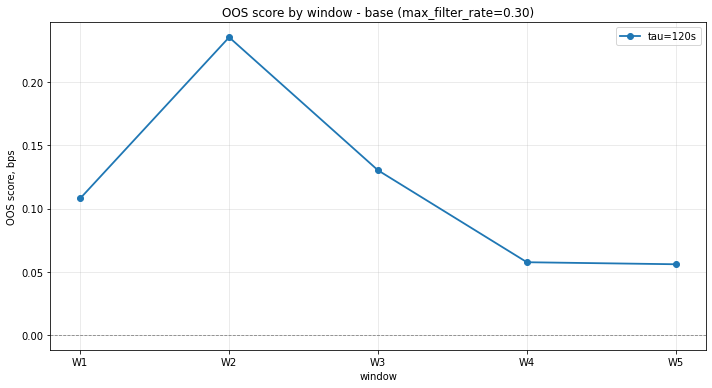

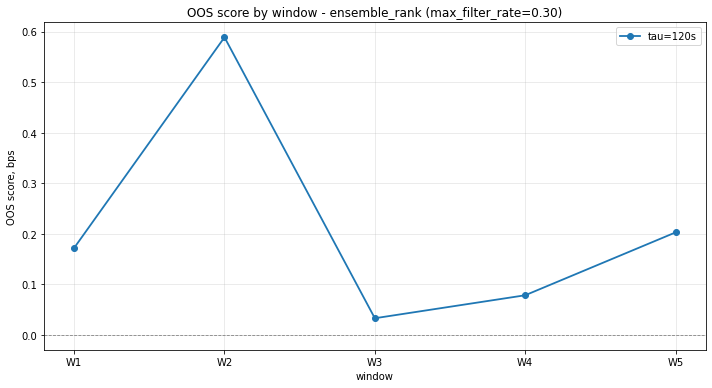

In [8]:
for variant in ("base", "ensemble_rank"):
    util.plot_score_by_window_one_chart(
        summary_030, variant=variant, taus=(TAU,),
        title=f"OOS score by window - {variant} (max_filter_rate=0.30)")

### Daily OOS score, production configuration

BTC_lgbm_huber_ensemble_rank_ensemble_rank_tau120s_fr0.3
Daily Score:
  mean   = +0.205075
  std    = 0.627382
  t-stat = +3.49  (mean / sem, 114 days)
  median = +0.168919
  min    = -1.279267
  max    = +4.059133
  >0 days: 79/114 (69%)
  <0 days: 35/114 (31%)

BTC_lgbm_huber_ensemble_rank_ensemble_rank_tau120s_fr0.3
Daily PnL kept:
  mean   = +0.162461
  std    = 0.865032
  t-stat = +2.01  (mean / sem, 114 days)
  median = +0.170875
  min    = -1.877586
  max    = +5.168396
  >0 days: 66/114 (58%)
  <0 days: 48/114 (42%)



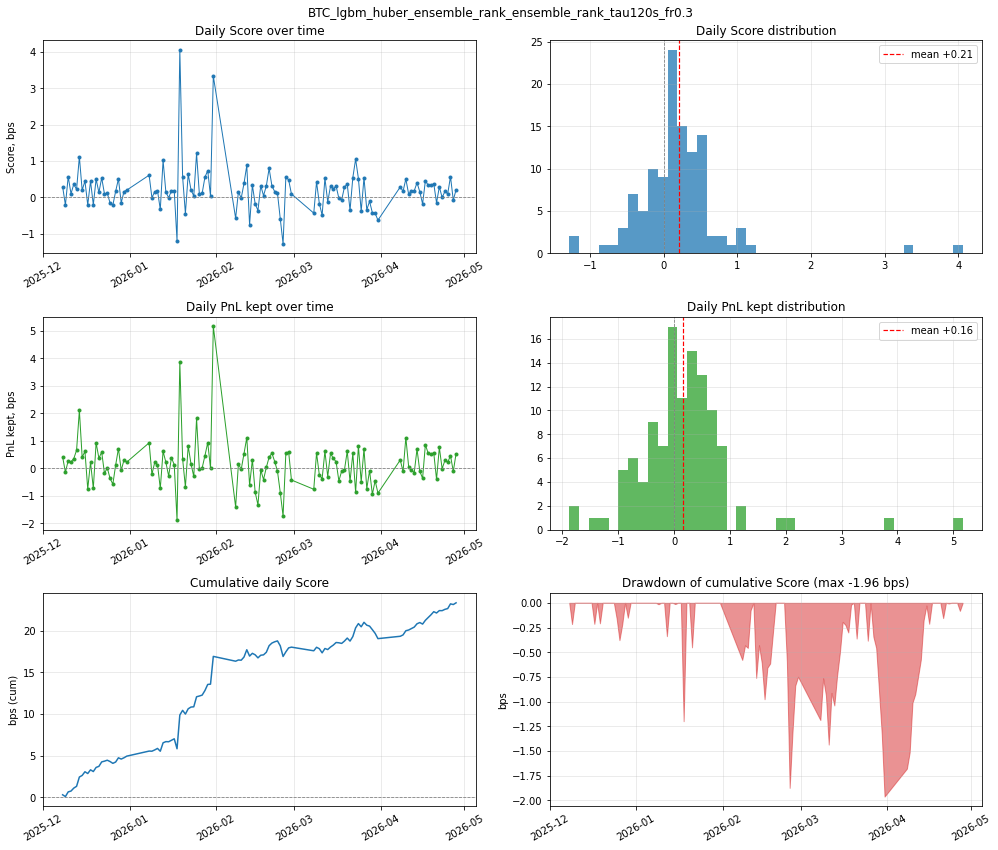

In [9]:
daily = util.plot_daily_score_distribution(
    results, variant="ensemble_rank", tau=TAU, max_filter_rate=0.30,
    instrument=INSTRUMENT, model_name="lgbm_huber_ensemble_rank")

### Paired comparison: production vs base

BTC lgbm tau=120s fr=0.3
Paired daily score, 114 common days:
  base                     mean = +0.103502
  ensemble_rank            mean = +0.205075
  diff (B - A)             mean = +0.101572
  paired t-stat = +2.29, B wins 70/114 days (61%)



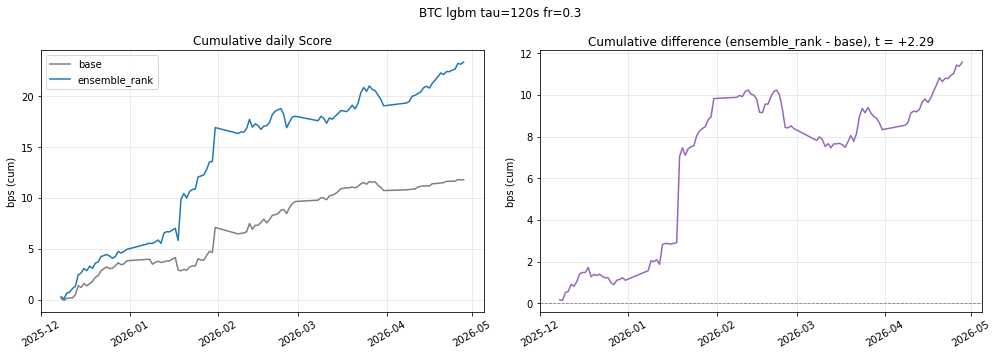

In [10]:
paired = util.compare_variants_daily(
    results, "base", "ensemble_rank", tau=TAU, max_filter_rate=0.30,
    instrument=INSTRUMENT, model_name="lgbm")

### Feature importance (production model, mean over windows)

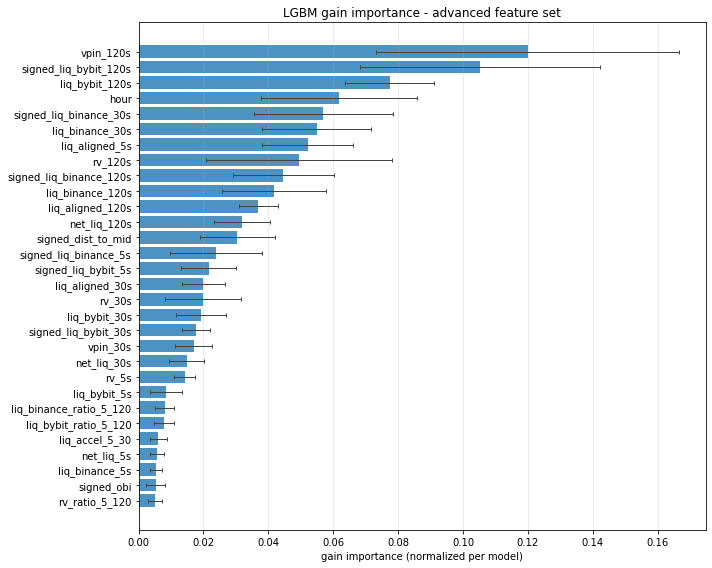

,feature,mean_importance,std_importance,n_models,sem_importance,interval
6,vpin_120s,0.119894,0.046578,20,0.010415,0.046578
28,signed_liq_bybit_120s,0.105339,0.036940,20,0.008260,0.036940
15,liq_bybit_120s,0.077379,0.013647,20,0.003051,0.013647
3,hour,0.061886,0.024055,20,0.005379,0.024055
24,signed_liq_binance_30s,0.056992,0.021493,20,0.004806,0.021493
11,liq_binance_30s,0.054861,0.016807,20,0.003758,0.016807
35,liq_aligned_5s,0.052092,0.014008,20,0.003132,0.014008
9,rv_120s,0.049451,0.028649,20,0.006406,0.028649
25,signed_liq_binance_120s,0.044607,0.015619,20,0.003493,0.015619
12,liq_binance_120s,0.041696,0.015963,20,0.003569,0.015963


In [11]:
fi = util.plot_lgbm_feature_importance(
    result_prod.models, top_n=30,
    title="LGBM gain importance - advanced feature set")
fi.head(15)

## 4. Summary

- The production configuration (advanced features + rank-aggregated LightGBM-Huber ensemble) improves the mean OOS score over the base configuration at every filter-rate budget, with the largest gap at `max_filter_rate = 0.30`.
- The gain accrues across the whole OOS period rather than in a few days; see the paired daily comparison and its t-statistic above.
- The turnover floor ($500k/day) never binds on this dataset; the active constraint is the filter-rate budget.
- Derived features (signed liquidation flow, liquidation battery) carry a large share of the model's gain importance; see the importance chart.
- To reproduce on another instrument: rebuild the enriched dataset (`BUILD_DATASET = True`, point `RAW_DIR` at the raw files) and rerun.